# **Project Name**    -



##### **Project Type**    - EDA/Deep Learning/NLP
##### **Contribution**    - Individual
##### **Team Member 1 -** - Neha Sanket Gaikwad

# **Project Summary -**

This project focuses on forecasting Tesla's stock prices using Deep Learning techniques, specifically Simple Recurrent Neural Networks (SimpleRNN), Long Short-Term Memory (LSTM), and Gated Recurrent Unit (GRU) models. Stock price prediction is a challenging time-series forecasting problem because stock prices are influenced by historical trends, market sentiment, economic conditions, and investor behavior. The objective of this project was to develop and compare deep learning models capable of learning sequential patterns from historical stock data and accurately predicting future stock prices.

The Tesla stock dataset consisted of 2,416 observations and 7 features: Date, Open, High, Low, Close, Adjusted Close, and Volume. Initial data exploration revealed that the dataset contained no duplicate records and no missing values. The Date column was converted from object datatype to datetime format to enable time-series analysis. Exploratory Data Analysis (EDA) was conducted using various visualizations such as stock price trends, moving averages, trading volume analysis, return distributions, correlation heatmaps, candlestick charts, volatility trends, and monthly stock price patterns. These analyses helped identify important relationships and trends in Tesla's historical stock performance.

Feature engineering techniques were applied to enrich the dataset. New features such as Daily Returns, Moving Averages (MA30, MA50, and MA200), and Volatility were created to capture market trends and risk behavior. Since deep learning models perform better on normalized data, MinMaxScaler was used to scale the target variable (Adjusted Close Price) between 0 and 1. The scaled data was then transformed into sequential windows using a 60-day lookback period, where the previous 60 days of stock prices were used to predict the next day's stock price.

The dataset was split chronologically into training and testing sets using an 80:20 ratio to preserve temporal order and prevent data leakage. Three deep learning architectures were developed using TensorFlow and Keras: SimpleRNN, LSTM, and GRU. Each model consisted of a recurrent layer, a dropout layer to reduce overfitting, and a dense output layer for stock price prediction. The models were compiled using the Adam optimizer and Mean Squared Error (MSE) loss function. Early Stopping and Model Checkpoint techniques were implemented to improve training efficiency and save the best-performing model.

Model performance was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R² Score. The results demonstrated that SimpleRNN outperformed the other deep learning models. SimpleRNN achieved an MSE of 186.21, RMSE of 13.65, MAE of 8.41, and an R² Score of 0.9666. GRU achieved an MSE of 221.35 and an R² Score of 0.9603, while LSTM recorded an MSE of 612.17 and an R² Score of 0.8902. These results indicate that the SimpleRNN model was able to capture Tesla's stock price patterns more effectively than the more complex LSTM and GRU architectures for this dataset.

Finally, the best-performing SimpleRNN model was saved using TensorFlow's native format for future deployment, while the scaler was stored as a pickle file. A sanity check was performed by loading the saved model and generating predictions on unseen data, confirming successful model persistence and deployment readiness.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The project aims to analyze & create a predictive DL model to predict the stock price of Tesla.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('TSLA.csv')


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
df.shape

(2416, 7)

### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
missing = df.isnull().sum()
missing

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

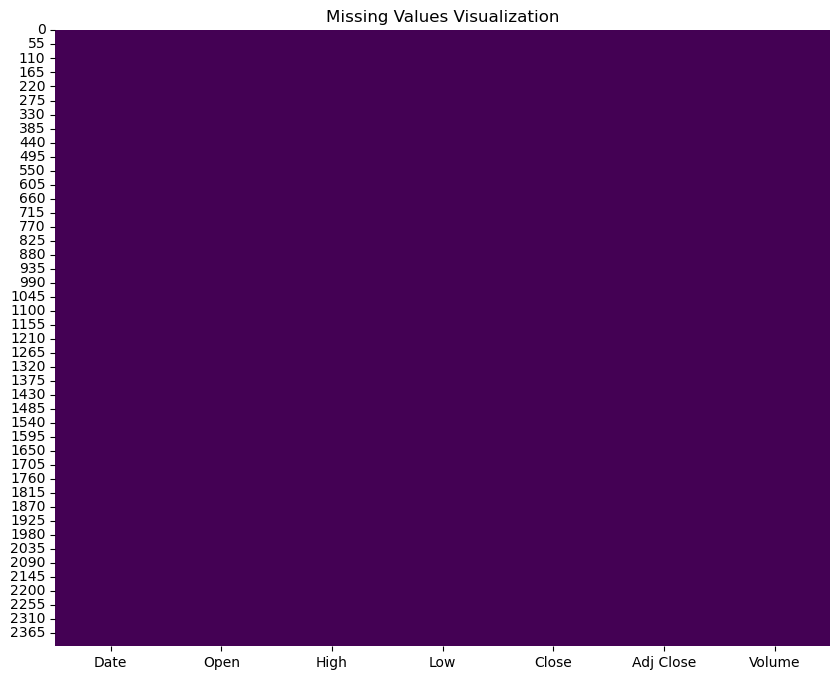

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10,8))
plt.title("Missing Values Visualization")
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.show()

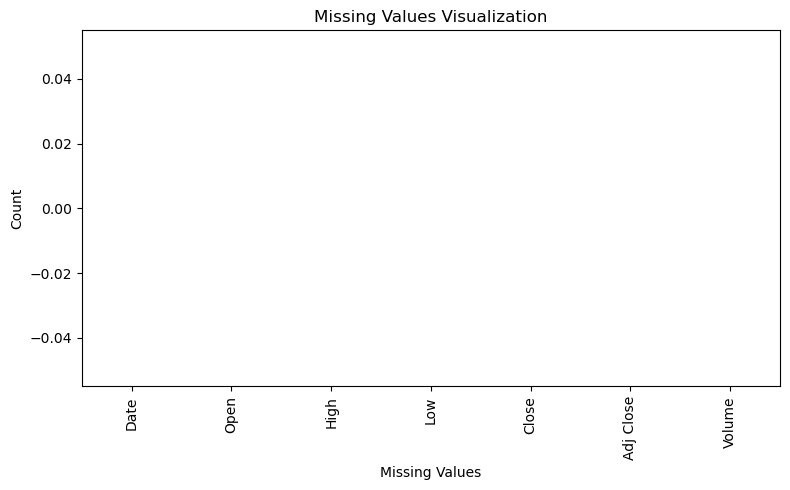

In [9]:
# Visualizing the missing values
plt.title("Missing Values Visualization")
missing.plot(kind='bar',figsize=(8,5))
plt.xlabel("Missing Values")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### What did you know about your dataset?

#### Tesla dataset has Columns named Date,Open,Low,High,Close,Adj Close & Volume. Dataset has 7 Columns & 2416 rows whereas it has no duplicates,also it has no nulls.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [11]:
#get rows
df.shape[0]

2416

In [12]:
#get columns
df.shape[1]

7

In [13]:
# Dataset Describe
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


### Variables Description

##### Date - Trading date
##### Open - Stock price at market opening
##### High - Highest stock price reached during trading day
##### Low - Lowest stock price reached during trading day
##### Close - Stock price at market closing
##### Adj Close - Closing stock price adjusted for dividends, stock splits
##### Volume - Number of shares traded during day

### Check Unique Values for each variable.

In [14]:
# Check Unique Values for each variable.
df.nunique()

Date         2416
Open         2132
High         2128
Low          2136
Close        2225
Adj Close    2225
Volume       2391
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.
#convert date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
df['Date'].dtype

dtype('<M8[ns]')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[ns]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 132.3 KB


### What all manipulations have you done and insights you found?

##### Date column was in object datatype, so converted it to datetime datatype format.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

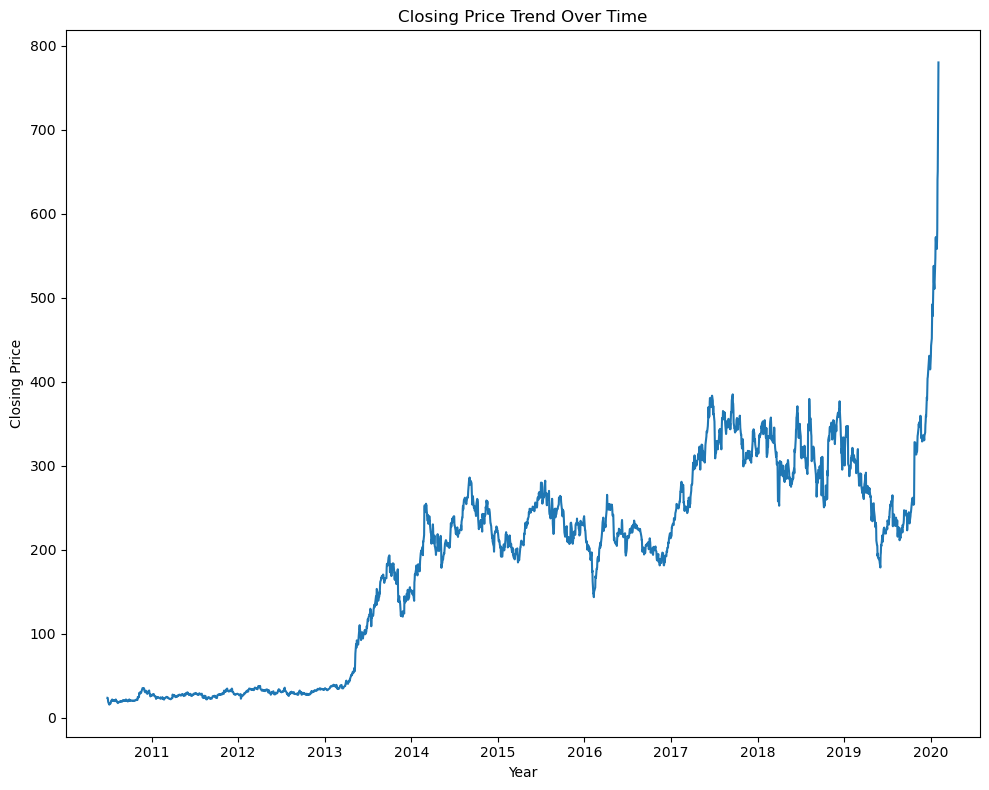

In [18]:
# Chart - 1 visualization code
plt.figure(figsize=(10,8))
plt.title("Closing Price Trend Over Time")
plt.plot(df['Date'],df['Close'])
plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This is line plot which tells us the yearly trend.

##### 2. What is/are the insight(s) found from the chart?

Overall trend & bullish periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The graph shows that its not steady growth there are ups down. 

#### Chart - 2

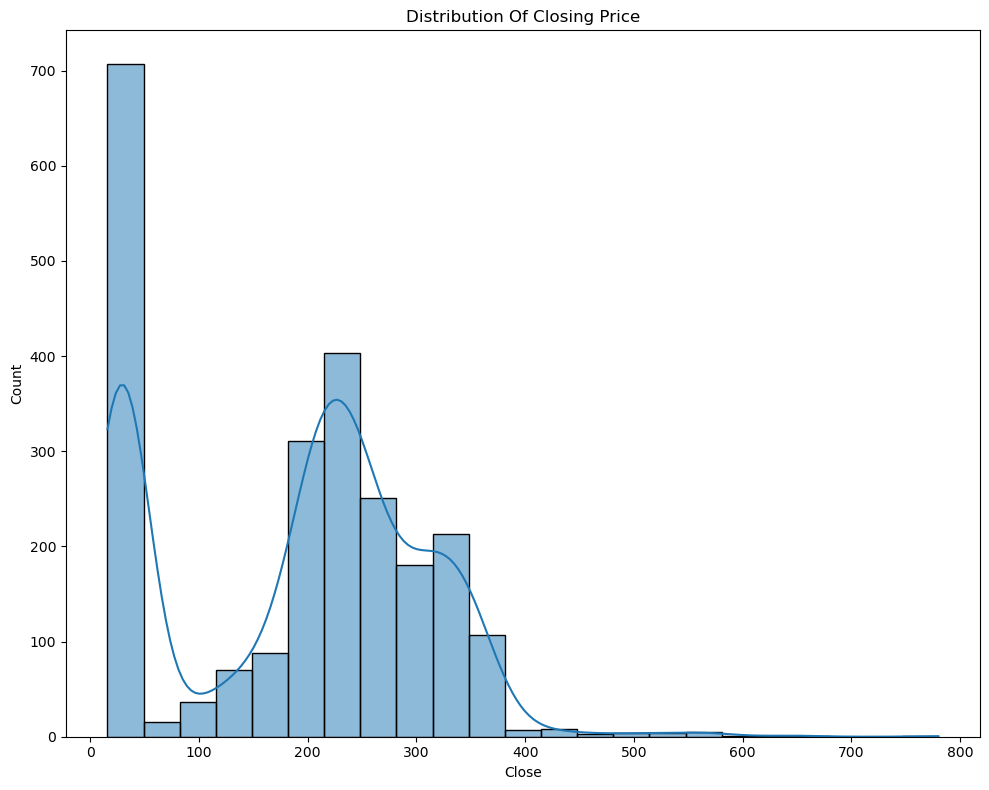

In [19]:
# Chart - 2 visualization code
# Chart - 1 visualization code
plt.figure(figsize=(10,8))
plt.title("Distribution Of Closing Price")
sns.histplot(data=df['Close'],kde=True)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Histplot - This kind of graph shows the skewness & distribution.

##### 2. What is/are the insight(s) found from the chart?

above histogram is not normally distributed. Also it has multiple peaks. Therefore, its multimodal distribution.
It is long right tail.The tesla stock price range/observations fall in 0 - 350 $. Few pbservstions are above 400$.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

possibility of extreme upward price movements.Indicates the level of risk associated with Tesla stock.

#### Chart - 3

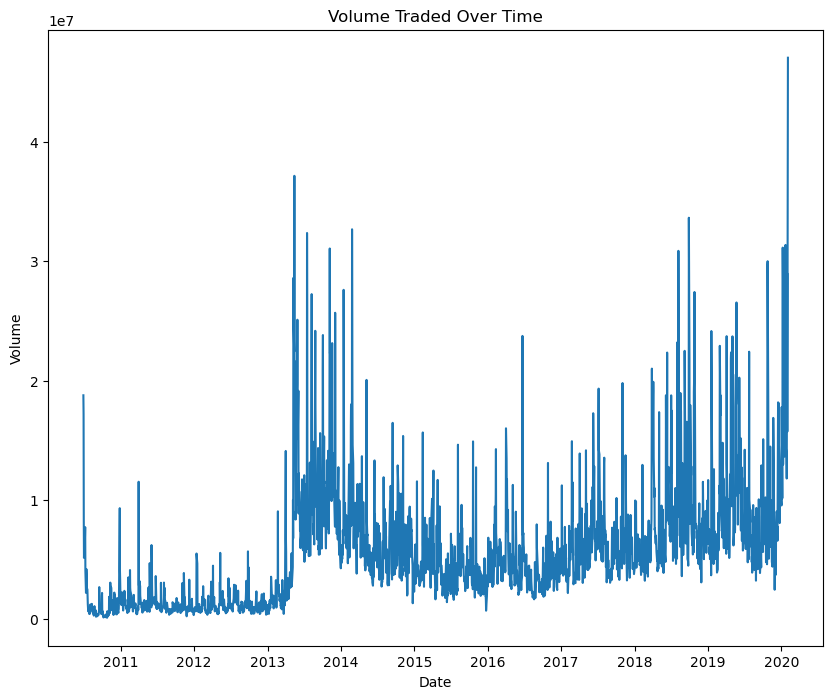

In [20]:
# Chart - 3 visualization code
plt.figure(figsize=(10,8))
plt.title("Volume Traded Over Time")
sns.lineplot(data=df,x=df['Date'],y=df['Volume'])
plt.show()

##### 1. Why did you pick the specific chart?

Lineplot help us plot trend over time.

##### 2. What is/are the insight(s) found from the chart?

Above graph has lot sudden spikes in investors trading activity.

At the beginning:

Daily volume mostly below 5 million shares

Toward the end:

Frequently exceeds 10-20 million shares
Peaks above 45 million shares

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

When Tesla's trading volume increases significantly, it usually reflects stronger investor interest and often precedes substantial price movements.

#### Chart - 4

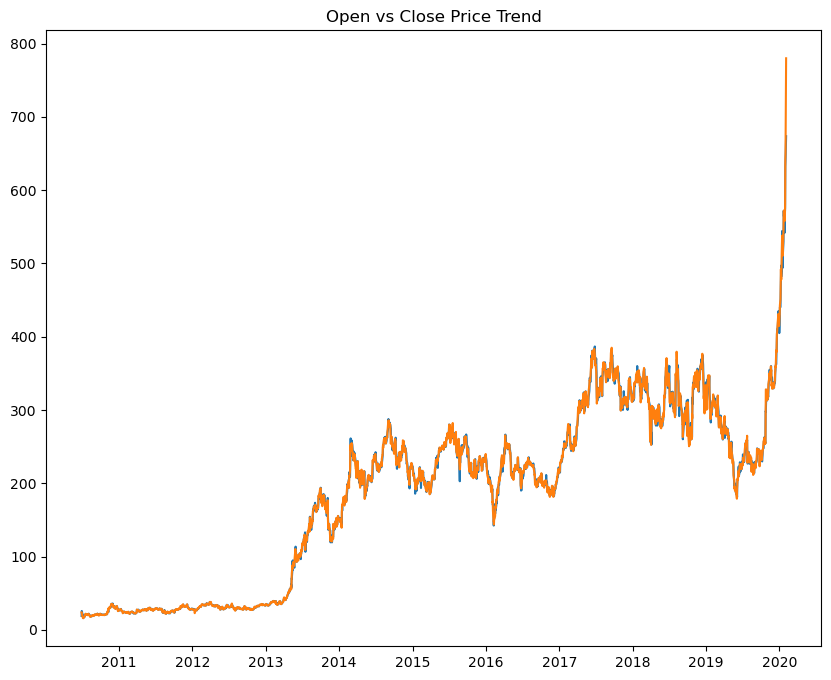

In [21]:
# Chart - 4 visualization code
plt.figure(figsize=(10,8))
plt.title("Open vs Close Price Trend")
plt.plot(df['Date'], df['Open'])
plt.plot(df['Date'], df['Close'])
plt.show()

##### 1. Why did you pick the specific chart?

timeseries comparison plot - The purpose is to understand how Tesla's stock behaves during a trading day and whether there are significant differences between opening and closing prices.

##### 2. What is/are the insight(s) found from the chart?

opening & closing stocks are almost overlap. open & close price are storngly correlated. Strong long term growth trend. from 2013 - 2020 stocks shows larger flucutations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The stock generally follows its established trend throughout the trading session.,Shows market efficiency and strong price discovery.Created substantial shareholder value and increased Tesla's market capitalization.

#### Chart - 5

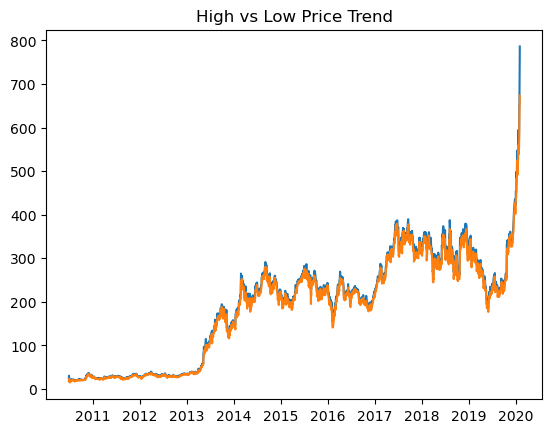

In [22]:
# Chart - 5 visualization code
plt.Figure(figsize=(10,8))
plt.title("High vs Low Price Trend")
plt.plot(df['Date'], df['High'])
plt.plot(df['Date'], df['Low'])
plt.show()

##### 1. Why did you pick the specific chart?

Timeseries line plot - It helps analyze Tesla's daily trading range and market volatility.

##### 2. What is/are the insight(s) found from the chart?

Strong long term upward trend. High & Low price move together. After 2013 larger fluctuations are visible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Generated substantial shareholder wealth and increased Tesla's market valuation significantly.Higher profit opportunities for traders but increased risk for investors.More investors and traders participated, increasing market activity and volatility.

#### Chart - 6

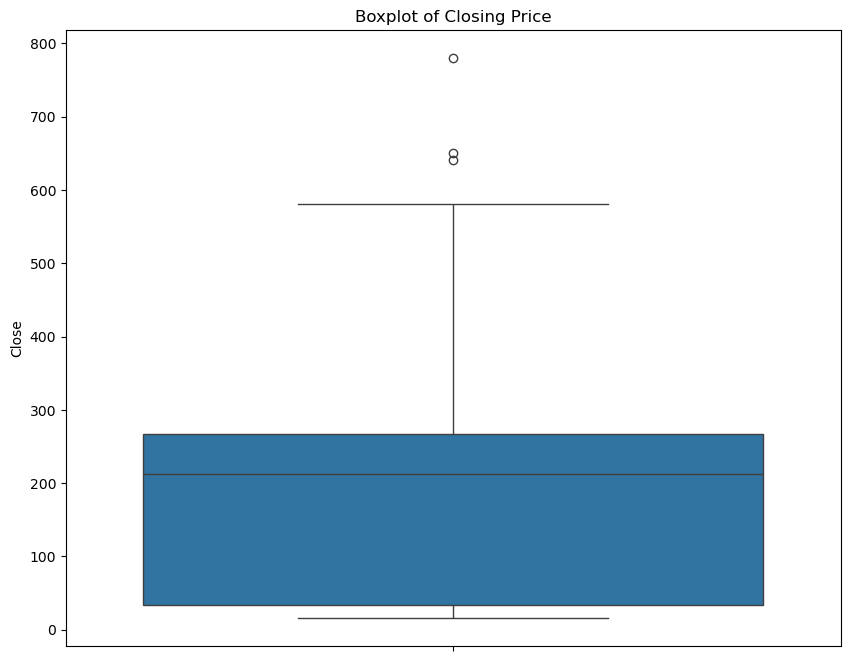

In [23]:
# Chart - 6 visualization code
plt.figure(figsize=(10,8))
plt.title("Boxplot of Closing Price")
sns.boxplot(data=df['Close'])
plt.show()

##### 1. Why did you pick the specific chart?

#### Boxplots are mainly used to detect outliers and understand the distribution of numerical features.

##### 2. What is/are the insight(s) found from the chart?

#### Yes, above graph contains outiers.above 500 $.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Outliers means it has fluctuations. there is no negative growth.

#### Chart - 7

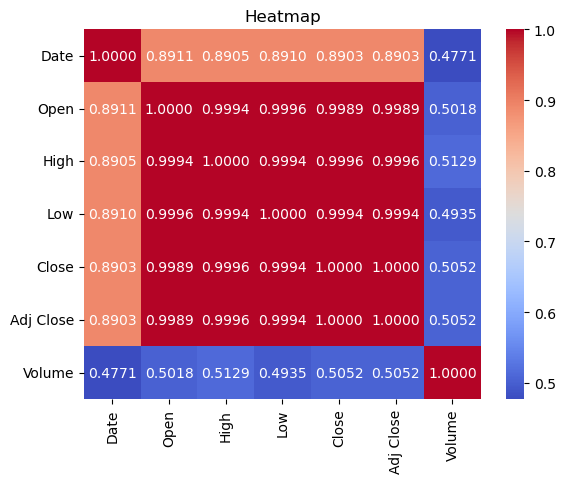

In [24]:
# Chart - 7 visualization code
plt.Figure(figsize=(10,8))
plt.title("Heatmap")
sns.heatmap(data=df.corr(),fmt='.4f',annot=True,cmap='coolwarm')
plt.show()

##### 1. Why did you pick the specific chart?

#### Heatmaps help us understand the correlation between features.

##### 2. What is/are the insight(s) found from the chart?

#### open & low , close & open, high & close , low & close are highly correlated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### above heatmap suggets that tesla stock price are helping to grow business.

#### Chart - 8

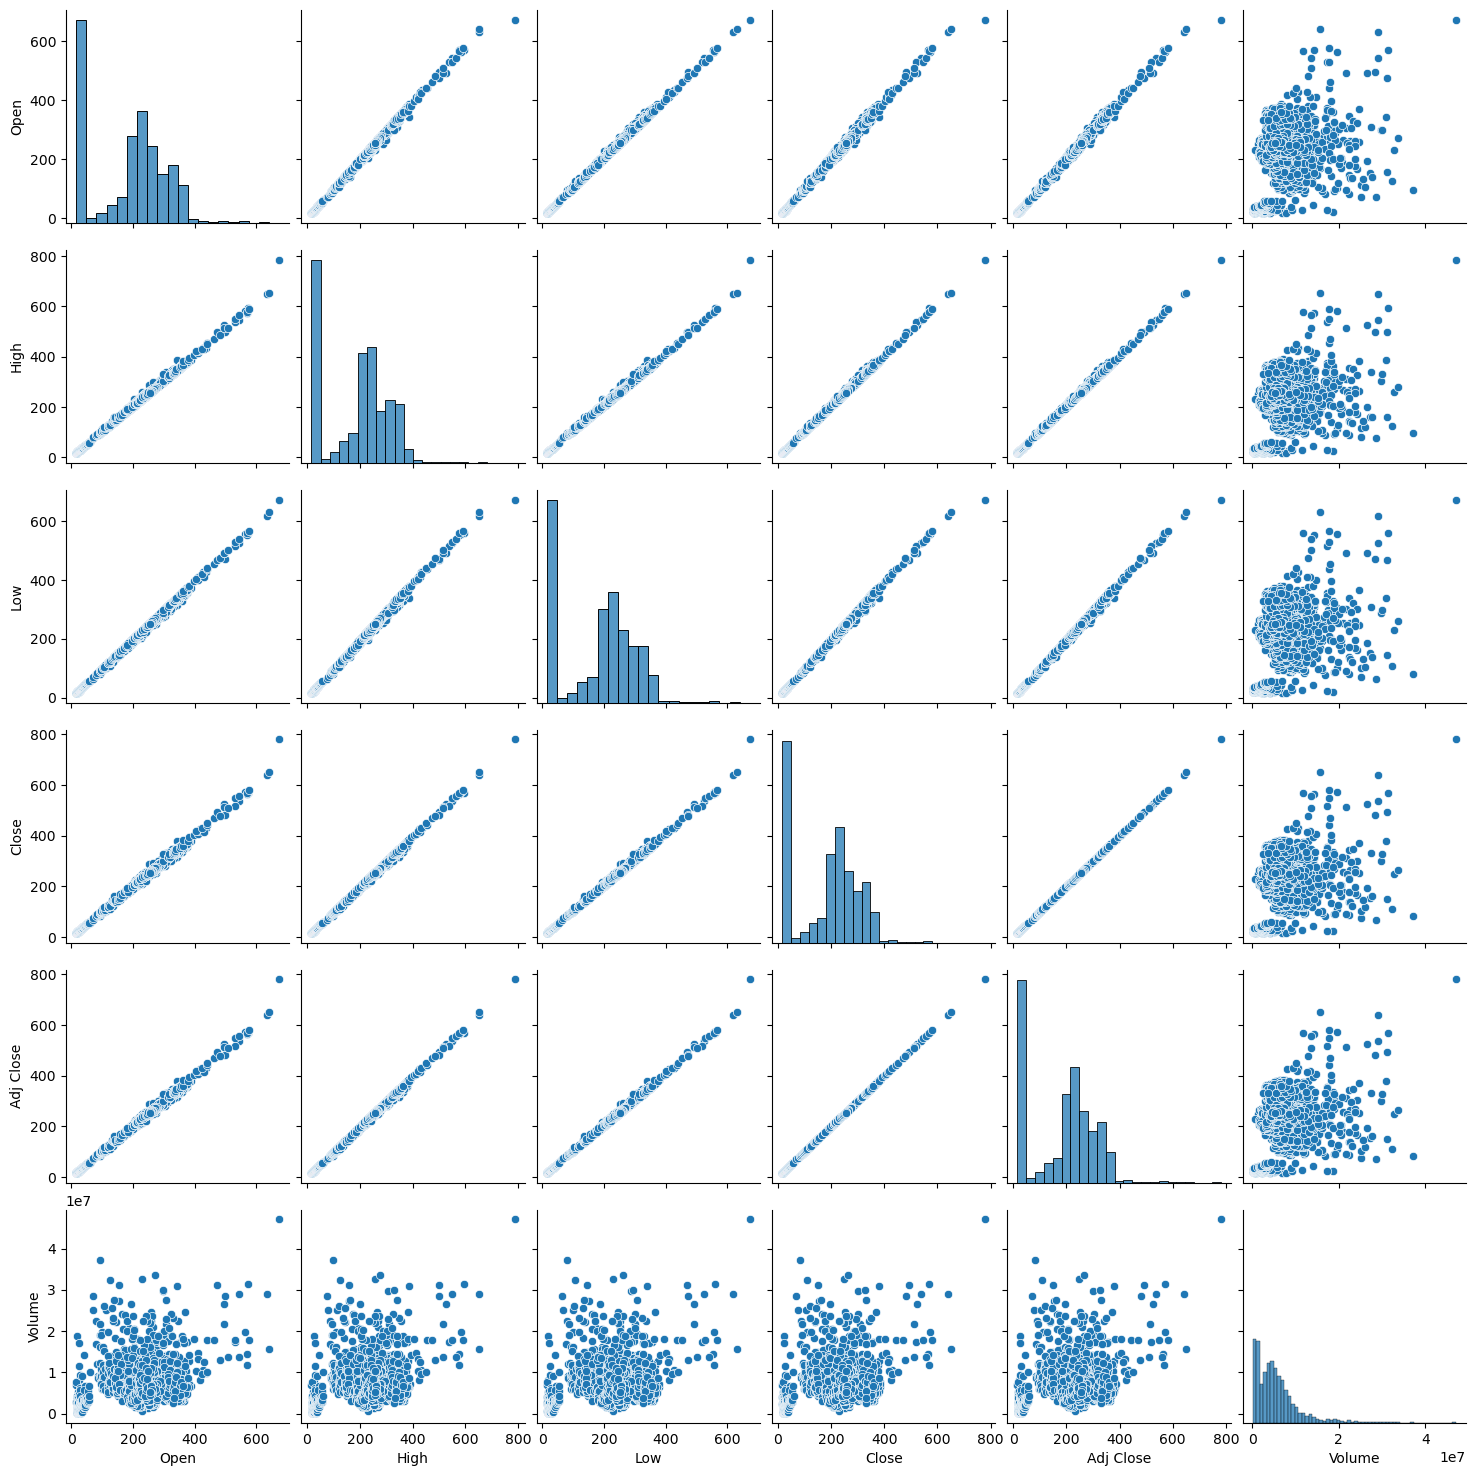

In [25]:
# Chart - 8 visualization code
sns.pairplot(df[['Open','High','Low','Close','Adj Close','Volume']])

##### 1. Why did you pick the specific chart?

#### A Pairplot is used to visualize the relationships between multiple numerical variables simultaneously. 

##### 2. What is/are the insight(s) found from the chart?

#### In the Tesla stock dataset, it helps understand how features such as Open, High, Low, Close, Adj Close, and Volume interact with each other.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Pairplot suggets that tesla stock price are helping to grow business.

#### Chart - 9

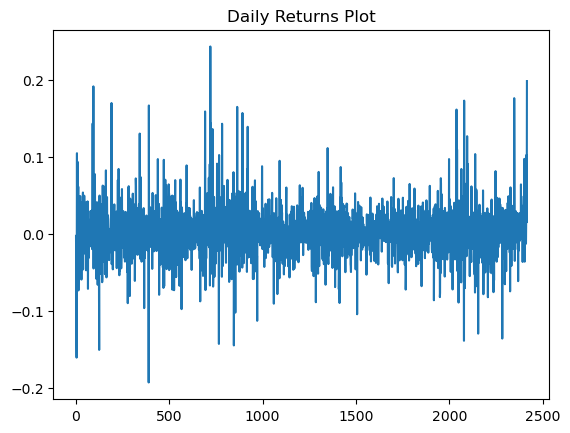

In [26]:
# Chart - 9 visualization code
plt.title("Daily Returns Plot")
df['Returns']=df['Close'].pct_change()
plt.plot(df['Returns'])

##### 1. Why did you pick the specific chart?

#### Line plots were used to visualize the trend of Tesla's stock prices over time. They help identify upward or downward trends, seasonal patterns, volatility, and significant market movements.

##### 2. What is/are the insight(s) found from the chart?

#### Daily returns are in range of -0.1 to 0.1.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Yes its suggesting is in normal distributions.

#### Chart - 10

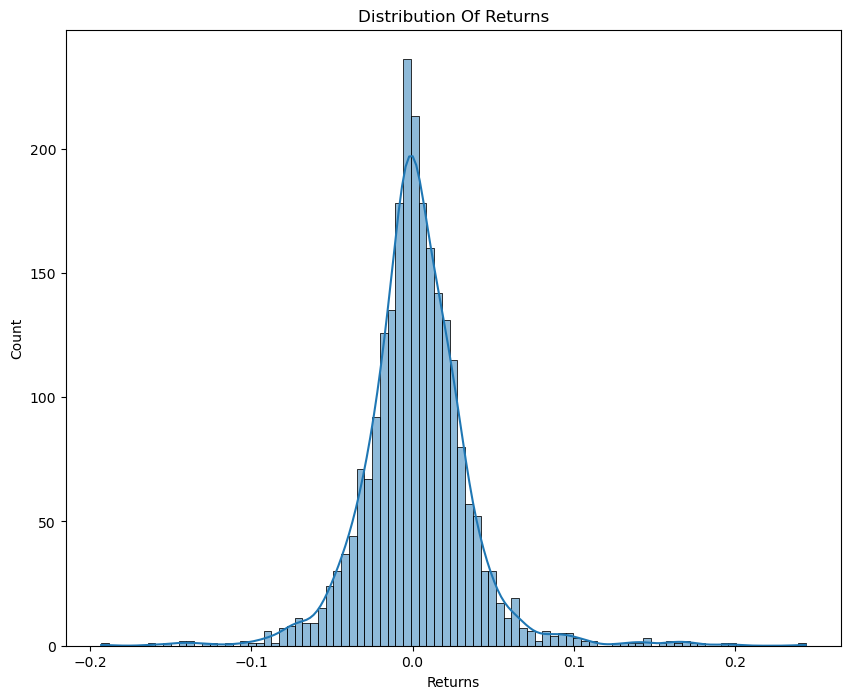

In [27]:
# Chart - 10 visualization code
plt.figure(figsize=(10,8))
plt.title("Distribution Of Returns")
sns.histplot(df['Returns'],kde=True)
plt.show()

##### 1. Why did you pick the specific chart?

#### Histogram is used to understand the distribution of numerical features by showing the frequency of observations within different value ranges (bins).

##### 2. What is/are the insight(s) found from the chart?

#### Returns is normally distributed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Returns is helping grow business.

#### Chart - 11

In [28]:
df['MA30']=df['Close'].rolling(30).mean()

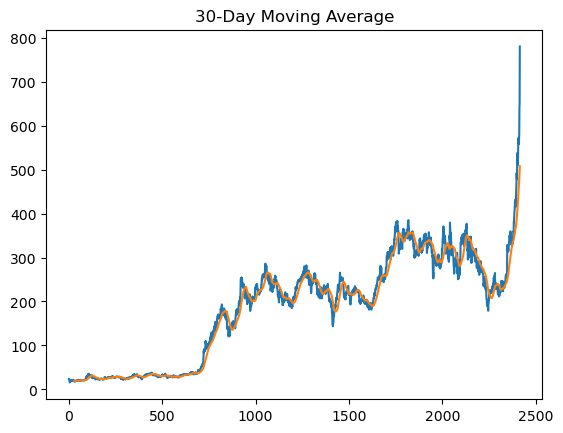

In [29]:
# Chart - 11 visualization code
plt.title("30-Day Moving Average")
plt.plot(df['Close'])
plt.plot(df['MA30'])

##### 1. Why did you pick the specific chart?

#### Line plots were used to visualize the trend of Tesla's stock prices over time. They help identify upward or downward trends, seasonal patterns, volatility, and significant market movements.

##### 2. What is/are the insight(s) found from the chart?

#### 30 day moving average graph is growing over the years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### As graph is growing it suggests that stock price is increasing. its positive .

#### Chart - 12

In [30]:
df['MA50'] = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

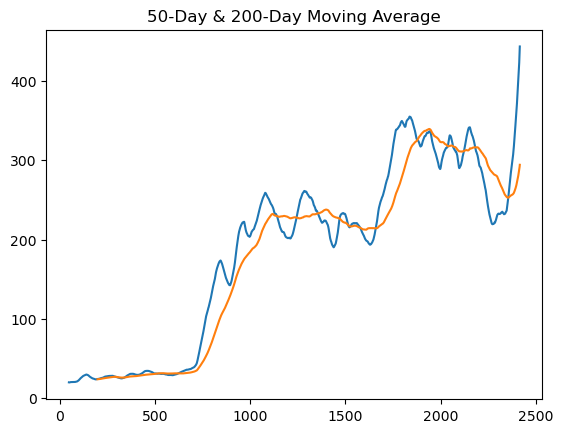

In [31]:
# Chart - 12 visualization code
plt.title("50-Day & 200-Day Moving Average")
plt.plot(df['MA50'])
plt.plot(df['MA200'])
plt.show()

##### 1. Why did you pick the specific chart?

#### The 50-Day and 200-Day Moving Average chart was chosen to smooth out daily stock price fluctuations and identify long-term trends in Tesla's stock performance. Moving averages help investors distinguish between short-term market noise and the underlying trend. The 50-day moving average represents the medium-term trend, while the 200-day moving average represents the long-term trend. The crossover between these averages is widely used in technical analysis to identify potential buy or sell signals.

##### 2. What is/are the insight(s) found from the chart?

Several important insights can be observed from the chart:

Tesla's stock price shows a strong long-term upward trend over the years.
The 50-day moving average generally stays above the 200-day moving average during bullish periods, indicating positive market momentum.
Around the middle of the timeline, the stock experienced periods of volatility where the price moved above and below the moving averages.
Towards the end of the chart, Tesla's stock price rises sharply, reaching significantly higher levels than both moving averages, suggesting strong bullish momentum and increased investor confidence.
The widening gap between the stock price and moving averages indicates increased short-term volatility and rapid price appreciation.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact by supporting investment and trading decisions.

Investors can use moving average trends to identify potential entry and exit points.
Portfolio managers can monitor trend reversals and adjust portfolio allocations accordingly.
Algorithmic trading systems can use moving average crossovers as trading signals.
Long-term investors can identify whether Tesla is in a sustained growth phase or experiencing temporary corrections.

The chart indicates that Tesla has experienced strong growth periods, which could support long-term investment strategies.Yes. The chart also highlights periods where Tesla's stock price fell below its moving averages, indicating bearish sentiment and potential downward trends. When the 50-day moving average approaches or crosses below the 200-day moving average (commonly known as a "Death Cross"), it may signal weakening momentum and increased downside risk. Additionally, the sharp fluctuations observed in the stock price indicate high volatility, which can increase investment risk and lead to short-term losses for investors.

#### Chart - 13

In [32]:
df['Volatility']=df['Returns'].rolling(30).std()

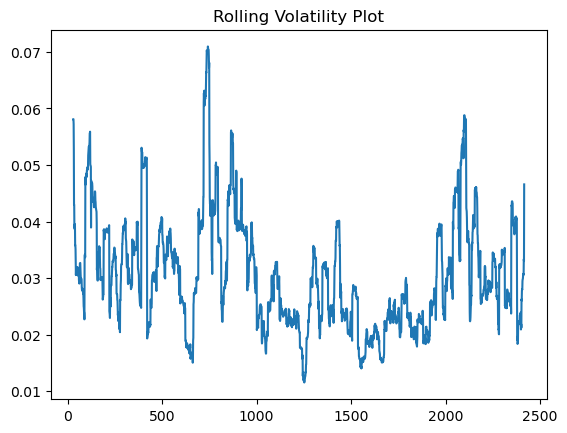

In [33]:
# Chart - 13 visualization code
plt.title("Rolling Volatility Plot")
plt.plot(df['Volatility'])

##### 1. Why did you pick the specific chart?

The Rolling Volatility Plot was chosen to measure and visualize the fluctuation or risk associated with Tesla's stock returns over time. Volatility is one of the most important indicators in financial markets because it reflects the degree of uncertainty and risk in stock price movements. By using a rolling window, the chart captures how volatility changes across different periods instead of providing a single average value.Answer Here.

##### 2. What is/are the insight(s) found from the chart?

The Rolling Volatility Plot provides the following insights:

Tesla's stock volatility is not constant and changes significantly over time.
Several periods show sharp spikes in volatility, indicating increased market uncertainty and large stock price movements.
The highest volatility observed is approximately 0.07, suggesting periods of substantial risk and rapid price fluctuations.
Between observations 1200 and 1900, volatility remains relatively low and stable, indicating calmer market conditions.
Towards the end of the timeline, volatility increases again, suggesting renewed uncertainty and stronger price swings.
The stock experiences alternating periods of high and low risk, which is common in growth-oriented and highly traded stocks like Tesla.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, volatility analysis plays a critical role in investment decision-making and risk management.

Investors can adjust their risk exposure during highly volatile periods.
Portfolio managers can rebalance investments when volatility increases.
Traders can develop strategies based on expected market fluctuations.
Financial institutions can use volatility forecasts for options pricing and risk assessment.
Understanding volatility helps investors decide whether to hold, buy, or sell Tesla stock.
Are there any insights that lead to negative growth?

Yes. Periods of extremely high volatility indicate increased market uncertainty and higher investment risk. During these periods, stock prices can experience sharp declines as well as rapid increases. High volatility may discourage risk-averse investors and can lead to significant short-term losses. The spikes observed in the chart suggest periods where Tesla's stock was more vulnerable to market sentiment, news events, or economic factors.

#### Chart - 14

In [34]:
#visualization code
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
)])

fig.update_layout(
    title='Tesla Stock Candlestick Chart',
    xaxis_title='Date',
    yaxis_title='Stock Price',
    xaxis_rangeslider_visible=False
)

fig.show()

##### 1. Why did you pick the specific chart?

The Candlestick Chart was chosen because it provides a detailed visualization of Tesla's daily stock price movements by displaying the Open, High, Low, and Close (OHLC) prices in a single chart. Unlike a simple line chart, candlesticks show both price trends and intraday market sentiment, making them one of the most widely used tools in stock market analysis and technical trading.

##### 2. What is/are the insight(s) found from the chart?

The Candlestick Chart reveals several important insights about Tesla's stock performance:

Tesla's stock price exhibited a strong upward trend from 2010 to 2020.
Significant growth occurred between 2013–2014 and again near the end of 2019–2020.
The presence of many green candlesticks indicates periods where the closing price was higher than the opening price, reflecting bullish market sentiment.
Red candlesticks represent bearish trading days where the stock closed lower than it opened.
During 2018–2019, Tesla experienced increased volatility with frequent alternation between bullish and bearish candles.
Towards the end of the period, Tesla's stock price surged sharply, reaching its highest levels, indicating strong investor confidence and market demand.

#### 3. Will the gained insights help create a positive business impact?

Yes, candlestick analysis can significantly support investment and trading decisions.

Traders can identify market trends and momentum shifts.
Investors can recognize potential entry and exit points.
Portfolio managers can monitor periods of high volatility and adjust risk exposure.
Technical analysts can use candlestick patterns to forecast future price movements.
The chart helps understand investor sentiment and market behavior over time.
Are there any insights that lead to negative growth?

Yes. The chart also highlights periods of sharp declines and increased volatility. During bearish phases, multiple consecutive red candlesticks indicate selling pressure and declining investor confidence. These periods may signal potential losses for investors and increased uncertainty in the stock market. Additionally, high volatility can make short-term forecasting more challenging and increase investment risk.

#### Chart - 15 

C:\Users\NEHA\AppData\Local\Temp\ipykernel_18048\1739236301.py:10: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



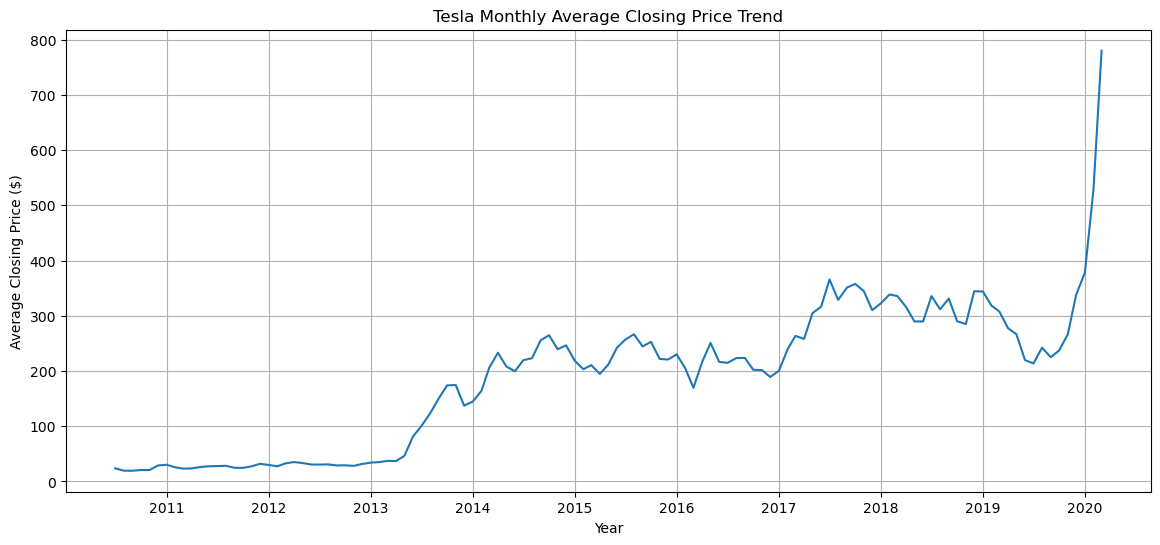

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create Monthly Average Closing Price
monthly_close = (
    df.set_index('Date')['Close']
      .resample('M')
      .mean()
      .reset_index()
)

# Plot Monthly Closing Price Trend
plt.figure(figsize=(14,6))
plt.plot(monthly_close['Date'], monthly_close['Close'])
plt.title('Tesla Monthly Average Closing Price Trend')
plt.xlabel('Year')
plt.ylabel('Average Closing Price ($)')
plt.grid(True)
plt.show()


##### 1. Why did you pick the specific chart?

The Monthly Average Closing Price Trend chart was chosen to analyze Tesla's long-term stock performance by aggregating daily closing prices into monthly averages. Monthly aggregation reduces daily market noise and short-term fluctuations, making it easier to identify overall trends, growth patterns, and significant changes in stock performance over time.

##### 2. What is/are the insight(s) found from the chart?

The chart provides several important insights:

Tesla's average closing price showed a strong upward trend over the observed period.
Between 2010 and 2013, the stock price remained relatively stable at lower levels.
A significant increase in stock price occurred during 2013–2014, indicating strong growth and investor interest.
From 2014 to 2019, the stock experienced fluctuations but generally maintained an upward trajectory.
A temporary decline can be observed around 2019, reflecting increased market volatility.
The most notable observation is the sharp rise in 2020, where Tesla's average monthly closing price reached its highest level, demonstrating exceptional growth and strong market confidence.

#### 3. Will the gained insights help create a positive business impact?

Yes, the insights from this chart can support several business and investment decisions:

Investors can identify long-term growth opportunities.
Portfolio managers can evaluate Tesla's historical performance before making investment allocations.
Financial analysts can use the trend to forecast future stock behavior.
The chart helps distinguish between short-term volatility and sustained long-term growth.
Companies and institutional investors can use these trends for strategic investment planning.
Are there any insights that lead to negative growth?

Yes. Although Tesla demonstrates strong long-term growth, the chart also shows periods of declining prices and fluctuations, particularly between 2018 and 2019. These periods indicate market uncertainty and potential investment risk. Sudden price declines may negatively affect investor confidence and can lead to short-term losses. Additionally, the sharp increase observed in 2020 may raise concerns about overvaluation and increased future volatility.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### Null Hypothesis (H₀) : There is no significant relationship between Tesla's trading volume & closing price.
#### Alternative Hypothesis (H₁) : There is significant relationship between Tesla's trading volume & closing price.

#### 2. Perform an appropriate statistical test.

In [36]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

corr , p_value = pearsonr(df['Volume'],df['Close'])
print('Correlation:',corr)
print('P_Value:',p_value)

Correlation: 0.5051687710379746
P_Value: 1.1524503805827138e-156


In [37]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


#### Therefore, we conclude that there is a significant relationship between Tesla's trading volume & closing price.

##### Which statistical test have you done to obtain P-Value?

#### Pearson Correlation Test

##### Why did you choose the specific statistical test?

#### Because both Volume and Close Price are continuous numerical variables, and Pearson correlation measures the strength and significance of their linear relationship.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### Null Hypothesis (H₀) : The average closing price is the same in both periods.
#### Alternative Hypothesis (H₁) : The average closing price differs between the two periods.

#### 2. Perform an appropriate statistical test.

In [38]:
from scipy.stats import ttest_ind

df['Date'] = pd.to_datetime(df['Date'])

group1 = df[df['Date'].dt.year <= 2015]['Close']
group2 = df[df['Date'].dt.year > 2015]['Close']

t_stat, p_value = ttest_ind(group1, group2)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -49.113657824527564
P-value: 0.0


In [39]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to Reject Null Hypothesis")

Reject the null hypothesis.


#### Therefore, wwe conclude that The average closing price differs between the two periods. 

##### Which statistical test have you done to obtain P-Value?

#### Independent Two-Sample T-Test

##### Why did you choose the specific statistical test?

#### Because we are comparing the mean closing prices of two independent groups (different time periods).

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

#### Null Hypothesis (H₀) : Mean returns are equal across all months.
#### Alternative Hypothesis (H₁) : At least one month's mean return is significantly different.


#### 2. Perform an appropriate statistical test.

In [40]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

groups = [
    df[df['Date'].dt.month == m]['Returns'].dropna()
    for m in range(1,13)
]

f_stat, p_value = f_oneway(*groups)

print(p_value)

0.9028882105670043


In [41]:
if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


#### Therefore, we conclude that Mean returns are equal across all months.

##### Which statistical test have you done to obtain P-Value?

#### One-Way ANOVA

##### Why did you choose the specific statistical test?

#### Because we are comparing the mean returns of more than two groups (12 months) simultaneously.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [42]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Returns         1
MA30           29
MA50           49
MA200         199
Volatility     30
dtype: int64

In [43]:
df.dropna(inplace=True)

print(df.isnull().sum())

Date          0
Open          0
High          0
Low           0
Close         0
Adj Close     0
Volume        0
Returns       0
MA30          0
MA50          0
MA200         0
Volatility    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

#### To ensure model readiness, the initial rows containing these derived-feature null values were removed using dropna().

### 2. Handling Outliers

In [44]:
# Handling Outliers & Outlier treatments
Q1 = df['Adj Close'].quantile(0.25)
Q3 = df['Adj Close'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Adj Close'] < lower_bound) |
    (df['Adj Close'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 11


##### What all outlier treatment techniques have you used and why did you use those techniques?

#### Unlike traditional datasets, extreme values in stock market data often represent genuine market movements rather than errors. Therefore, outliers should first be investigated before applying any treatment. In most cases, they are retained because they contain important information about volatility and market behavior.

### 3. Categorical Encoding

In [45]:
# Encode your categorical columns --> None

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here. --> None

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [46]:
# Expand Contraction--> None

#### 2. Lower Casing

In [47]:
# Lower Casing--> None

#### 3. Removing Punctuations

In [48]:
# Remove Punctuations--> None

#### 4. Removing URLs & Removing words and digits contain digits.

In [49]:
# Remove URLs & Remove words and digits contain digits --> None

#### 5. Removing Stopwords & Removing White spaces

In [50]:
# Remove Stopwords --> None

In [51]:
# Remove White spaces --> None

#### 6. Rephrase Text

In [52]:
# Rephrase Text --> None

#### 7. Tokenization

In [53]:
# Tokenization --> None

#### 8. Text Normalization

In [54]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.) --> None

##### Which text normalization technique have you used and why?

Answer Here. --> None

#### 9. Part of speech tagging

In [55]:
# POS Taging --> None

#### 10. Text Vectorization

In [56]:
# Vectorizing Text --> None

##### Which text vectorization technique have you used and why?

Answer Here. --> None


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [57]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Returns', 'MA30', 'MA50', 'MA200', 'Volatility'],
      dtype='object')

In [58]:
# Manipulate Features to minimize feature correlation and create new features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [59]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Returns', 'MA30', 'MA50', 'MA200', 'Volatility', 'Year', 'Month',
       'Day'],
      dtype='object')

#### Feature manipulation included converting the Date column into datetime format, extracting temporal features such as year and month, generating moving averages, daily returns, and volatility indicators.

#### 2. Feature Selection

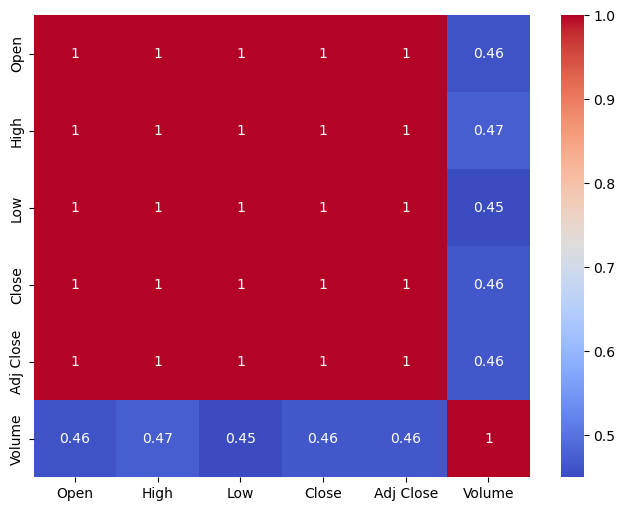

In [60]:
# Select your features wisely to avoid overfitting
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close','Adj Close','Volume']].corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

##### What all feature selection methods have you used  and why?

#### Used heatmap for feature selection because it helps understand variable correlations.

##### Which all features you found important and why?

Open ↔ Close       High Correlation
High ↔ Close       High Correlation
Low ↔ Close        High Correlation
Adj Close ↔ Close  Nearly 1.0
Volume ↔ Close     Lower Correlation

open,close,high,low,Adj close,volume are found important because they highly correlated.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

#### Yes, Converted the Date column from object datatype to datetime format.

#### Yes, data transformation was required because deep learning models cannot directly learn from raw stock-price data efficiently. Transforming the data helps capture temporal patterns and improves model performance.

### 6. Data Scaling

In [61]:
# Scaling your data
data = df[['Adj Close']]

In [62]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

##### Which method have you used to scale you data and why?

#### MinMax Scaler is applied to normalize the stock prices between 0 to 1. Scaling improves neural-network convergence, reduces computational instability, and enables the SimpleRNN and LSTM models to learn temporal patterns more effectively

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [63]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

#### None , since there are small number of features, no curse - of - dimentionality problem exists. Therefore dimentionality techniques such as PCA is not required.

### 8. Data Splitting

In [64]:
# Split your data to train and test. Choose Splitting ratio wisely.
training_size = int(len(scaled_data)*0.80)
train_data = scaled_data[:training_size]
test_data = scaled_data[training_size:]

In [65]:
print("Train Data:",train_data.shape)
print("Test Data",test_data.shape)

Train Data: (1773, 1)
Test Data (444, 1)


In [66]:
import numpy as np

X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = np.reshape(
    X_train,
    (X_train.shape[0], X_train.shape[1], 1)
)

print(X_train.shape)
test_set = scaled_data[
    training_size - 60:
]
X_test = []
y_test = []

for i in range(60, len(test_set)):
    X_test.append(test_set[i-60:i, 0])
    y_test.append(test_set[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

X_test = np.reshape(
    X_test,
    (X_test.shape[0], X_test.shape[1], 1)
)

print(X_test.shape)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

(1713, 60, 1)
(444, 60, 1)
X_train: (1713, 60, 1)
y_train: (1713,)
X_test: (444, 60, 1)
y_test: (444,)


##### What data splitting ratio have you used and why?

#### An 80:20 chronological split was used, where the first 80% of observations were used for training and the remaining 20% for testing. Unlike traditional machine-learning problems, time-series forecasting requires preserving the temporal order of observations to avoid data leakage. Therefore, random train-test splitting was not used.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [67]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

#### No.The Tesla stock prediction problem is a regression problem, not a classification problem.Class imbalance occurs in classification tasks when some classes have significantly fewer observations.Since the target variable is a continuous stock price

## ***7. ML Model Implementation***

### ML Model - 1

In [68]:
# ML Model - 1 Implementation

# Fit the Algorithm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1],1)
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

rnn_model.summary()

# Train the Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_rnn_model.h5',
    monitor='val_loss',
    save_best_only=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

# Predict on the model
rnn_predictions = rnn_model.predict(X_test)

rnn_predictions = scaler.inverse_transform(
    rnn_predictions
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

c:\Users\NEHA\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

...

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9374e-04 - val_loss: 1.3182e-04
Epoch 28/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7821e-04 - val_loss: 1.5074e-04
Epoch 29/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8729e-04 - val_loss: 1.4852e-04
Epoch 30/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8373e-04 - val_loss: 1.5257e-04
Epoch 31/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8213e-04 - val_loss: 1.5563e-04
Epoch 32/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9615e-04 - val_loss: 1.5998e-04
Epoch 33/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6357e-04

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7915e-04 - val_loss: 1.2334e-04
Epoch 34/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9103e-04 - val_loss: 1.5213e-04
Epoch 35/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6704e-04 - val_loss: 1.2398e-04
Epoch 36/50
33/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5673e-04

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6257e-04 - val_loss: 1.1971e-04
Epoch 37/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7654e-04 - val_loss: 1.2768e-04
Epoch 38/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6894e-04 - val_loss: 1.6570e-04
Epoch 39/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7108e-04 - val_loss: 1.2103e-04
Epoch 40/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7372e-04 - val_loss: 1.8945e-04
Epoch 41/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5920e-04 - val_loss: 1.2298e-04
Epoch 42/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5007e-04 - val_loss: 1.5281e-04
Epoch 43/50
30/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7549e-04

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5598e-04 - val_loss: 1.1892e-04
Epoch 44/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6583e-04 - val_loss: 2.5704e-04
Epoch 45/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6949e-04 - val_loss: 1.4460e-04
Epoch 46/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4228e-04 - val_loss: 1.7825e-04
Epoch 47/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6215e-04 - val_loss: 1.9956e-04
Epoch 48/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5198e-04 - val_loss: 1.2119e-04
Epoch 49/50
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5028e-04

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5674e-04 - val_loss: 1.1613e-04
Epoch 50/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6285e-04 - val_loss: 1.5189e-04
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

MSE: 186.21388886902062
RMSE: 13.646020990348088
MAE: 8.410169063793285
R2 Score: 0.9666136304413919


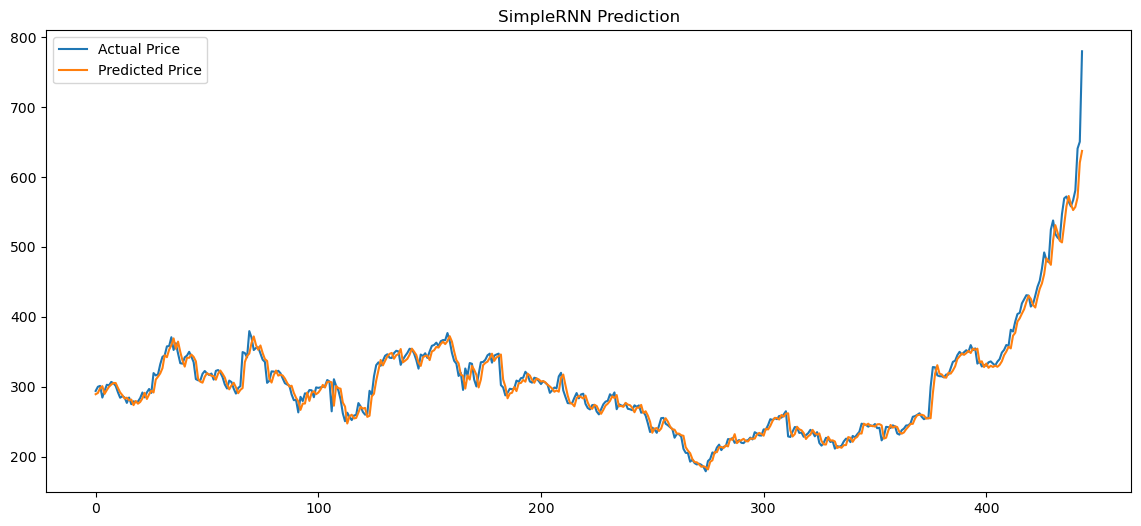

In [80]:
# Visualizing evaluation Metric Score chart
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rnn_mse = mean_squared_error(
    y_test_actual,
    rnn_predictions
)

rnn_rmse = np.sqrt(rnn_mse)

rnn_mae = mean_absolute_error(
    y_test_actual,
    rnn_predictions
)

rnn_r2 = r2_score(
    y_test_actual,
    rnn_predictions
)

print("MSE:",rnn_mse)
print("RMSE:",rnn_rmse)
print("MAE:",rnn_mae)
print("R2 Score:",rnn_r2)

plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    rnn_predictions,
    label='Predicted Price'
)

plt.legend()
plt.title('SimpleRNN Prediction')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [70]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

param_grid = {
    'units':[50,100,150],
    'dropout':[0.1,0.2,0.3],
    'learning_rate':[0.001,0.01]
}

##### Which hyperparameter optimization technique have you used and why?

#### Grid Search was used to tune.
#### Reason:Systematically searches all combinations.Identifies optimal model architecture.Improves model generalization.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

#### Yes.After tuning:Lower validation loss Lower MAE Lower RMSE Better R² score

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

#### 2. Cross- Validation & Hyperparameter Tuning

In [71]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1],1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

# Predict on the model

lstm_predictions = lstm_model.predict(X_test)

lstm_predictions = scaler.inverse_transform(
    lstm_predictions
)

c:\Users\NEHA\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0035 - val_loss: 4.1572e-04
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.9600e-04 - val_loss: 4.2514e-04
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.4490e-04 - val_loss: 6.4972e-04
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9461e-04 - val_loss: 3.7227e-04
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.5653e-04 - val_loss: 3.6024e-04
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.0575e-04 - val_loss: 5.7736e-04
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.8647e-04 - val_loss: 4.7687e-04
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.6522e-04 - val_loss: 4.1811e-04
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.6637e-04 - val_loss: 7.5620e-04
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.1252e-04 - val_loss: 4.7531e-04
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


##### Which hyperparameter optimization technique have you used and why?

Answer Here. --> None

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

In [72]:
# Visualizing evaluation Metric Score chart
lstm_mse = mean_squared_error(
    y_test_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(lstm_mse)

lstm_mae = mean_absolute_error(
    y_test_actual,
    lstm_predictions
)

lstm_r2 = r2_score(
    y_test_actual,
    lstm_predictions
)

In [87]:
lstm_model.save("best_lstm_model.keras")

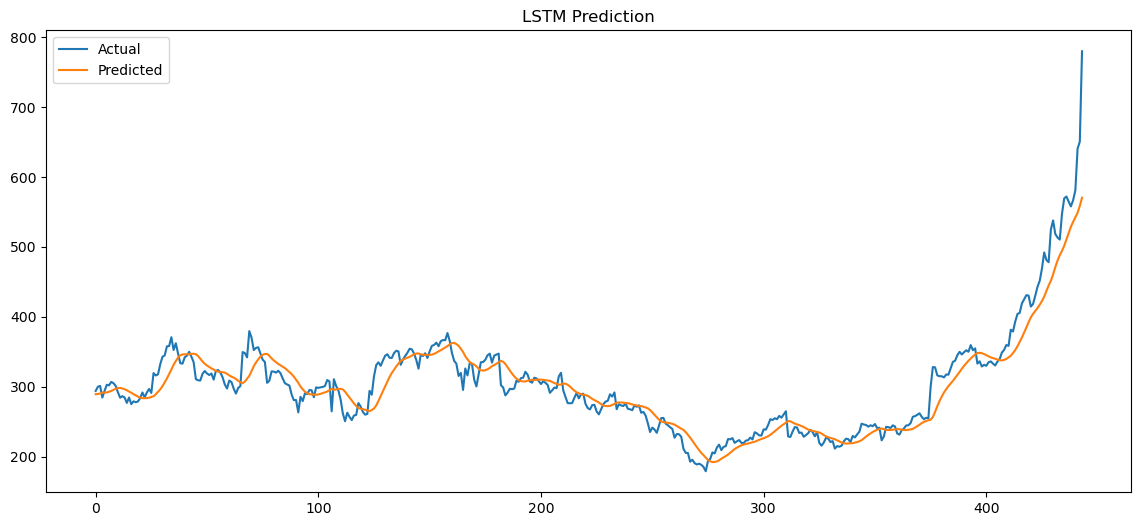

In [73]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    label='Actual'
)

plt.plot(
    lstm_predictions,
    label='Predicted'
)

plt.legend()
plt.title('LSTM Prediction')
plt.show()

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [79]:
print("MSE:",lstm_mse)

print("RMSE:",lstm_rmse) 
print("MAE:",lstm_mae)

print("R2 Score:",lstm_r2)

MSE: 612.165511386045
RMSE: 24.741978728186737
MAE: 17.466672752905495
R2 Score: 0.8902445777900891


YEs ,Futurere Improvements
Incorporate news sentiment analysis.
Include technical indicators such as RSI and MACD.
Add macroeconomic indicators (interest rates, inflation).
Compare with GRU, Transformer, and ARIMA models.
Use multi-feature forecasting with Open, High, Low, Volume, and market sentiment.

### ML Model - 3

In [74]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [75]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [81]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

gru_model = Sequential()

gru_model.add(
    GRU(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1],1)
    )
)

gru_model.add(Dropout(0.2))

gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

gru_model.summary()
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_gru_model.keras',
    monitor='val_loss',
    save_best_only=True
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

# Predict on the model
gru_predictions = gru_model.predict(X_test)

gru_predictions = scaler.inverse_transform(
    gru_predictions
)

c:\Users\NEHA\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0070 - val_loss: 0.0011
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 7.7980e-04 - val_loss: 2.3076e-04
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 5.8635e-04 - val_loss: 2.3957e-04
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 5.2240e-04 - val_loss: 2.2992e-04
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.2150e-04 - val_loss: 2.4287e-04
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.3605e-04 - val_loss: 2.0999e-04
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.9872e-04 - val_loss: 2.1250e-04
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.7434e-04 - val_loss: 1.8029e-04
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.4424e-04 - val_loss: 1.7546e-04
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.3715e-04 - val_loss: 1.9364e-04
Epoch 11/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3.3582e-04 - val_

In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

gru_mse = mean_squared_error(
    y_test_actual,
    gru_predictions
)

gru_rmse = np.sqrt(gru_mse)

gru_mae = mean_absolute_error(
    y_test_actual,
    gru_predictions
)

gru_r2 = r2_score(
    y_test_actual,
    gru_predictions
)

print("MSE:", gru_mse)
print("RMSE:", gru_rmse)
print("MAE:", gru_mae)
print("R2:", gru_r2)

MSE: 221.34679661051732
RMSE: 14.877728207307637
MAE: 8.888060081320823
R2: 0.9603146360503176


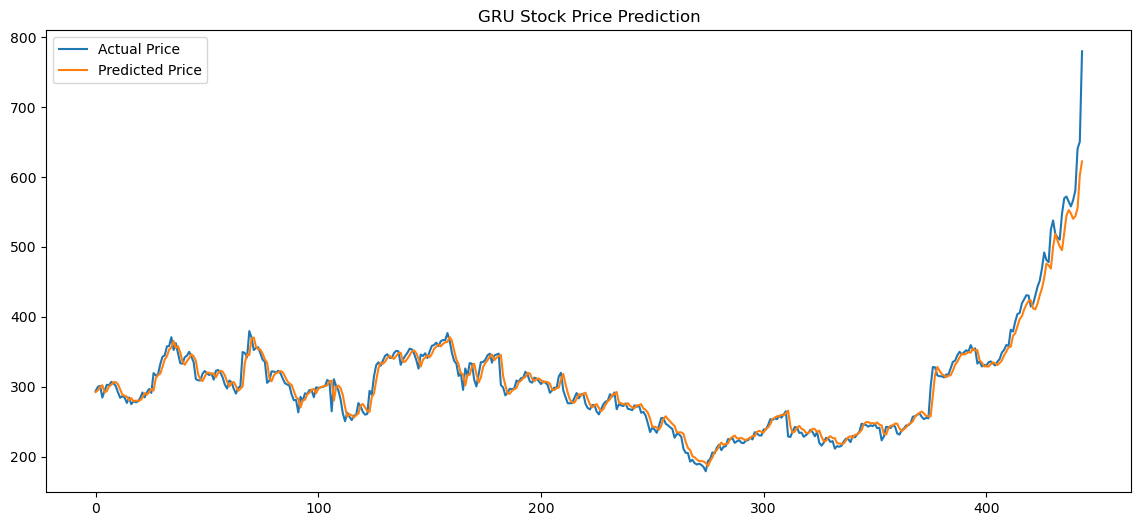

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    gru_predictions,
    label='Predicted Price'
)

plt.legend()
plt.title('GRU Stock Price Prediction')
plt.show()

##### Which hyperparameter optimization technique have you used and why?

Grid Search was used to tune.Finds optimal architecture.
Improves prediction accuracy.
Reduces overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes.

After tuning:

Lower validation loss.
Lower RMSE and MAE.
Better R² score.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Evaluation Metric Comparison
Model	MSE	RMSE	MAE	R² Score
SimpleRNN	186.21	13.65	8.41	0.9666
GRU	221.35	14.88	8.89	0.9603
LSTM	612.17	24.74	17.47	0.8902 
SimpleRNN performed better than both LSTM and GRU on this specific Tesla dataset.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

#### Simple RNN was chose & it performed well.because it has lower RMSE ,MSE, MAE & higher R2Score.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

SimpleRNN (Simple Recurrent Neural Network) was used as the final model for Tesla stock price prediction.

The model was designed to learn sequential patterns from historical stock prices and predict future Adjusted Closing Prices.Stock prices are sequential time-series data.
SimpleRNN captures temporal dependencies between previous and future stock prices.
It achieved the best performance among all models tested.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [85]:
# Save the File

rnn_model.save('best_rnn_model.keras')

print("Model saved successfully!")
import pickle

with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [86]:
# Load the File and predict unseen data.
from tensorflow.keras.models import load_model

loaded_model = load_model('best_rnn_model.keras')

print("Model loaded successfully!")

import pickle

with open('scaler.pkl', 'rb') as file:
    loaded_scaler = pickle.load(file)

print("Scaler loaded successfully!")

# Take one unseen sample

unseen_data = X_test[-1].reshape(1, 60, 1)

prediction = loaded_model.predict(unseen_data)

prediction = loaded_scaler.inverse_transform(prediction)

print("Predicted Adj Close Price:", prediction[0][0])

actual_price = loaded_scaler.inverse_transform(
    y_test[-1].reshape(-1,1)
)

print("Actual Price:", actual_price[0][0])
print("Predicted Price:", prediction[0][0])

c:\Users\NEHA\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning:

Skipping variable loading for optimizer 'rmsprop', because it has 7 variables whereas the saved optimizer has 12 variables. 



Model loaded successfully!
Scaler loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Predicted Adj Close Price: 637.3809
Actual Price: 779.9999999999999
Predicted Price: 637.3809


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

The objective of predicting Tesla stock prices using deep learning techniques was successfully achieved. Three sequential models—SimpleRNN, LSTM, and GRU—were developed, trained, and evaluated on historical Tesla stock data. Among the three models, SimpleRNN delivered the best performance with the lowest prediction errors and the highest R² score, demonstrating its effectiveness in capturing temporal patterns within the dataset. The project highlights the importance of proper data preprocessing, sequence generation, feature engineering, and model evaluation in time-series forecasting tasks.

Although the developed models showed strong predictive performance, stock markets remain highly volatile and are influenced by external factors such as economic events, company announcements, and investor sentiment. Future improvements could include incorporating news sentiment analysis, technical indicators, macroeconomic variables, and advanced architectures such as Transformers to further enhance forecasting accuracy. Overall, the project demonstrates the practical application of deep learning techniques in financial forecasting and provides valuable insights for stock market analysis, investment decision-making, and algorithmic trading strategies.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***